11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 151ms/step - loss: 0.1743 - val_loss: 0.0914
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 148ms/step - loss: 0.0881 - val_loss: 0.0840
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 143ms/step - loss: 0.0832 - val_loss: 0.0809
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 148ms/step - loss: 0.0807 - val_loss: 0.0788
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - loss: 0.0789 - val_loss: 0.0775
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


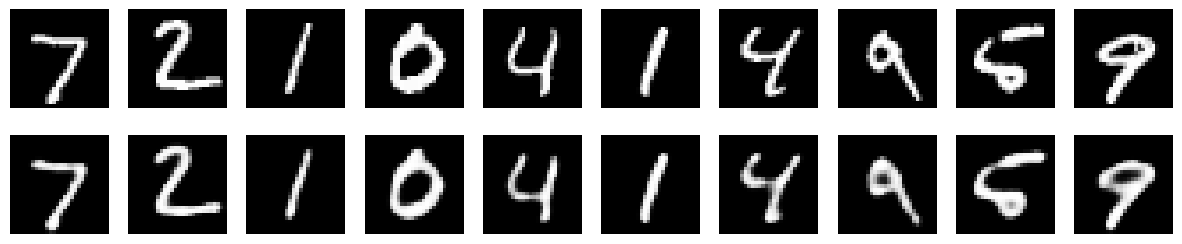

In [1]:
#saniyagoutam prn:23070521126
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Encoder
encoder = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2, padding="same"),
    tf.keras.layers.Conv2D(8, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2, padding="same")
])

# Decoder
decoder = tf.keras.Sequential([
    tf.keras.layers.Conv2D(8, 3, activation="relu", padding="same"),
    tf.keras.layers.UpSampling2D(2),
    tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    tf.keras.layers.UpSampling2D(2),
    tf.keras.layers.Conv2D(1, 3, activation="sigmoid", padding="same")
])

# Autoencoder
autoencoder = tf.keras.Sequential([encoder, decoder])

# Compile
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

# Train
autoencoder.fit(x_train, x_train, epochs=5, batch_size=128,
                validation_data=(x_test, x_test))

# Reconstruct images
reconstructed = autoencoder.predict(x_test[:10])

# Compare original and reconstructed images
plt.figure(figsize=(15, 3))

for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()